# Practica 20
***
### El objetivo de esta actividad es que efectúes un análisis de regresión Ridge y Lasso que permita construir un modelo predictivo a una base de datos real de manera que puedas generar pronósticos adecuados.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
import os
os.chdir("/Users/Darki/OneDrive/Escritorio")

In [2]:
df = pd.read_excel("FuelConsumptionCo2.xlsx")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230


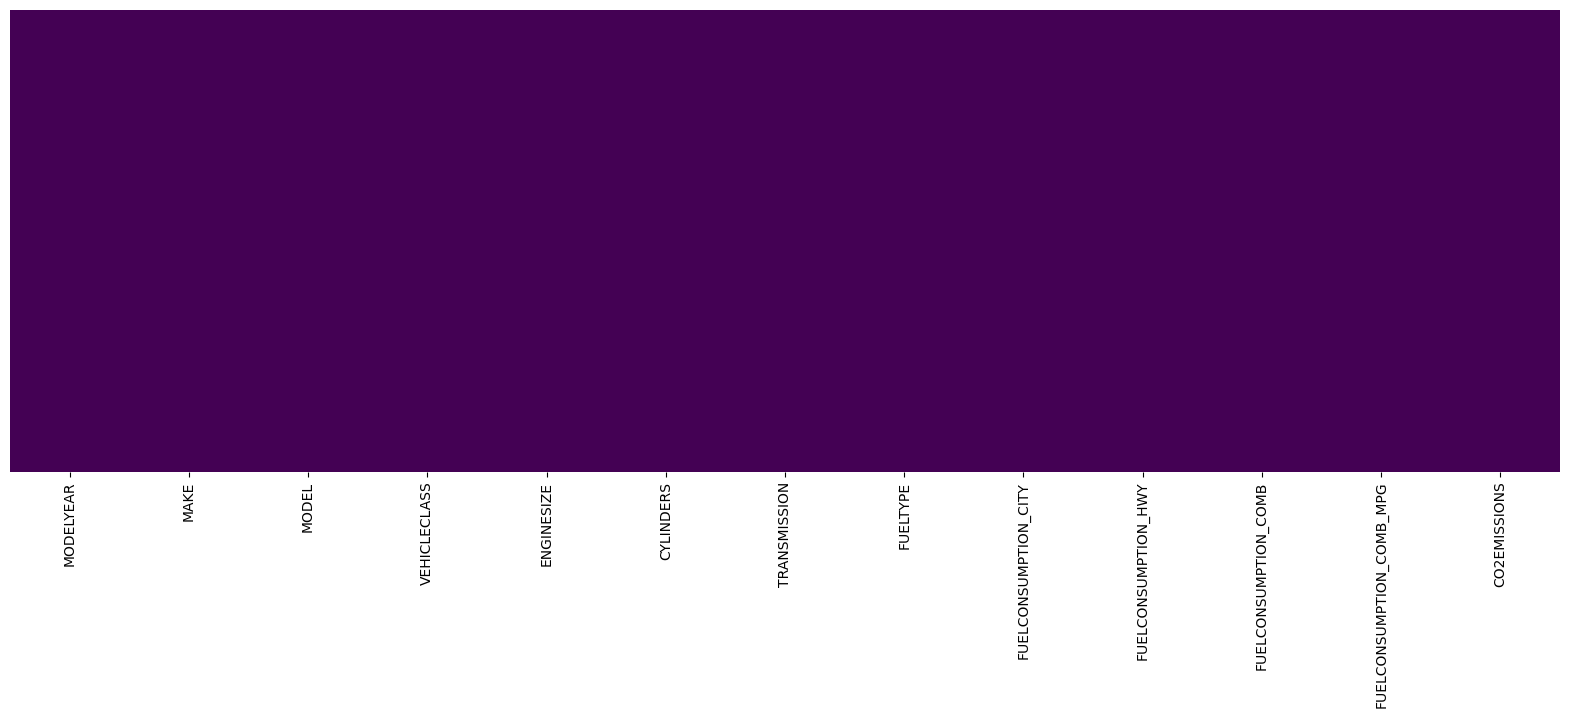

In [3]:
#No parece haber ningun dato faltante 
plt.figure(figsize=(20,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [4]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

### ============================================================================
* ### Elimine las columnas de tipo categórico de la base de datos y verifique que no existan datos nulos que deban ser eliminados de manera previa al análisis.
***

In [5]:
# las columnas ENGINESIZE, CYLINDERS y TRANSMISSION las contemplo como categoricas por que a pesar de ser numeros, cada una sigue siendo parte de una categoria de auto.

df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS','TRANSMISSION', 'FUELTYPE'],axis= 1, inplace=True )
df.columns

Index(['FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [6]:
df.head()

,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,9.9,7.0,8.6,33,200
1,12.6,9.4,11.2,25,263
2,11.0,8.6,9.9,29,232
3,11.3,9.1,10.3,27,242
4,11.2,8.0,9.8,29,230


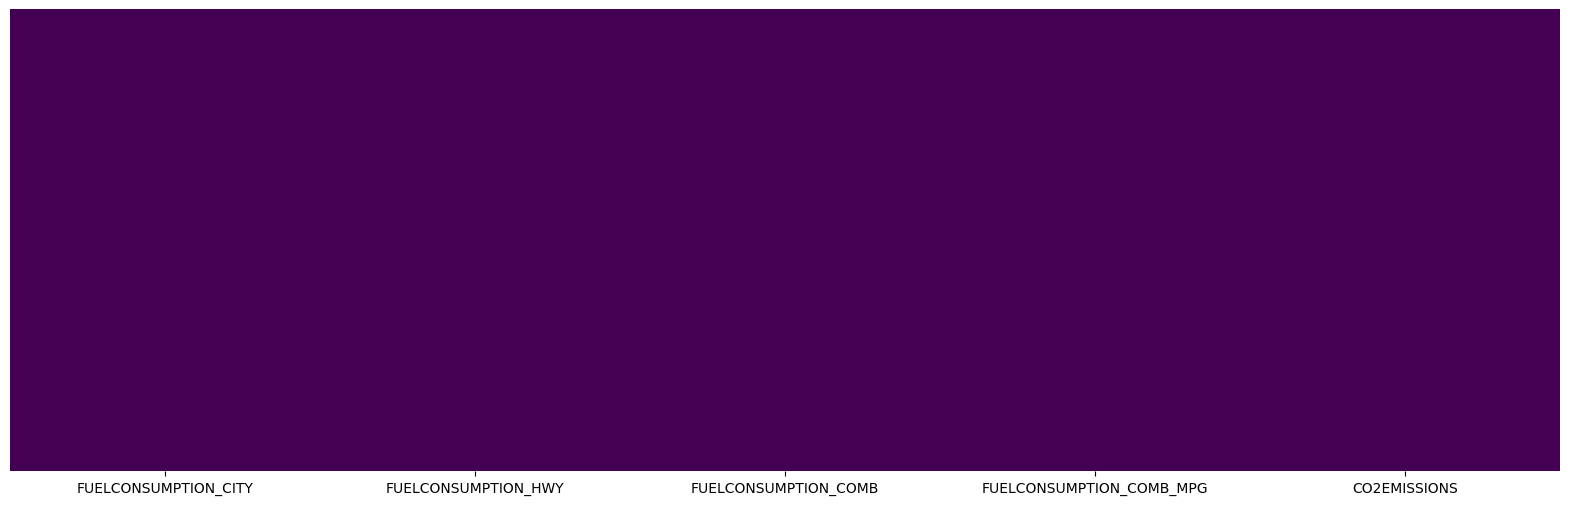

In [7]:
plt.figure(figsize=(20,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

### ============================================================================
* ### Realice un análisis de regresión múltiple para pronosticar la variable “CO2 EMISSIONS” con las variables remanentes. Obtenga los indicadores de bondad de ajuste correspondientes (R cuadrada, Error medio absoluto, etc.). Utilice los coeficientes resultantes y pronostique la primera observación de la base de prueba. ¿Coincide su resultado con aquel obtenido con la instrucción “predict”? Explique.
***

In [8]:
X = df.drop('CO2EMISSIONS', axis = 1)
Y = df['CO2EMISSIONS']

In [9]:
# Divicion en grupos de entrenamiento training y prueba
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split (X, Y, test_size =0.30, random_state=1)


In [10]:
# COnstruccion de modelo de regresion lineal multiple
from sklearn.linear_model import LinearRegression
linreg= LinearRegression()
linreg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Impresion de coeficiente de regresion
print ('Intercepto: ', linreg.intercept_)
print ('Coeficientes: ',linreg.coef_)

Intercepto:  95.93361319267356
Coeficientes:  [10.85607131  5.91025898  0.71589393 -1.33087138]


### Pronóstico manual de la primera observación

Para pronosticar manualmente la primera observación de la base de prueba, se utilizó la ecuación estimada por el modelo de regresión lineal múltiple:

El intercepto obtenido fue 95.9336 y los coeficientes fueron 10.8561, 5.9103, 0.7159 y -1.3309. Se multiplicó cada coeficiente por el valor correspondiente de la primera observación de **x_test** y se sumaron los productos al intercepto.

**El pronóstico manual obtenido fue aproximadamente 323.9685**. La instrucción **predict produjo también un valor aproximado de 323.9685.**

**Por lo tanto, ambos resultados coinciden.** Esto ocurre porque la función predict realiza internamente la misma operación matemática: multiplica los valores de las variables explicativas por los coeficientes estimados y agrega el intercepto.

In [12]:
# Primera observación de la base de prueba
primera_observacion = x_test.iloc[0]

print("Primera observación:")
print(primera_observacion)

Primera observación:
FUELCONSUMPTION_CITY        15.6
FUELCONSUMPTION_HWY         12.7
FUELCONSUMPTION_COMB        14.3
FUELCONSUMPTION_COMB_MPG    20.0
Name: 786, dtype: float64


In [13]:
# Pronóstico manual:
# intercepto + suma de cada variable multiplicada por su coeficiente
pronostico_manual = (linreg.intercept_+ np.dot(primera_observacion.values, linreg.coef_))

# Pronóstico de la misma observación mediante predict
pronostico_predict = linreg.predict(x_test.iloc[[0]])[0]

print("\nPronóstico manual:", pronostico_manual)
print("Pronóstico con predict:", pronostico_predict) 
if pronostico_manual == pronostico_predict:
    print('Los Pronóstico son correctos')
else:
    print('Los Pronóstico son incorrectos')


Pronóstico manual: 323.9684701962643
Pronóstico con predict: 323.9684701962643
Los Pronóstico son correctos


In [14]:
# Predicciones
y_pred = linreg.predict(x_test)

In [15]:
#Calculo de indicadores de la bndad de ajuste
from sklearn.metrics import r2_score
from sklearn import metrics

In [16]:
# Impresion de indicadores de bondad de ajuste
print ('Valor de R Cuadrada: ' , r2_score (y_test,y_pred))
print ('Error absoluto medio: ', metrics.mean_absolute_error(y_test,y_pred))
print('Error cuadrado medio: ', metrics.mean_squared_error(y_test, y_pred))
print ('Raiz del error cuadratico medio: ', np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Valor de R Cuadrada:  0.9809388418270502
Error absoluto medio:  5.694519664627067
Error cuadrado medio:  72.94435631403712
Raiz del error cuadratico medio:  8.540746824138807


# Resultados

### El modelo de regresión lineal múltiple presento los siguientes resultados:

El valor **R2** indica aproximadamente una variabilidad del **98.09%**. Así mismo el **error absoluto medio (MAE)** muestra que las predicciones se alejan en promedio **5.69 unidades** del valor real. Mas se observa que **la raíz del error cuadrático medio (RMSE)** es de **8.54 unidades** lo que sugiere que hay errores relativamente más grandes que los que el MAE muestra.


### ============================================================================
* ### Repita el ejercicio 3 pero aplicando un modelo de **regresión Ridge** mediante el valor de Alpha óptimo.
  ***

In [17]:

#normalizado con sklearn nuevo
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Definicion un rango de prueba para alpha
alpha_range = np.logspace(-2, 2, 200)
from sklearn.linear_model import RidgeCV
ridgeregcv = RidgeCV (alphas = alpha_range, scoring = 'neg_mean_squared_error')
ridgeregcv.fit(x_train_scaled, y_train)
print("Alpha óptimo: ",ridgeregcv.alpha_)

Alpha óptimo:  4.500557675700498


In [18]:
#Prediccion mediante el mejor valor de Alpha
y_pred = ridgeregcv.predict(x_test_scaled)


print ('Valor de R Cuadrada: ' , r2_score (y_test,y_pred))
print ('Error absoluto medio: ', metrics.mean_absolute_error(y_test,y_pred))
print('Error cuadrado medio: ', metrics.mean_squared_error(y_test, y_pred))
print ('Raiz del error cuadratico medio: ', np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Valor de R Cuadrada:  0.9809292156918796
Error absoluto medio:  5.725127957187483
Error cuadrado medio:  72.98119417181215
Raiz del error cuadratico medio:  8.542903146577991


# Resultado

### El modelo Ridge presento los siguientes resultados:
Los resultados de Ridge son prácticamente iguales a los de la regresión lineal múltiple, aunque Ridge resultó ligeramente peor en la base de prueba.


### ============================================================================

* ### Repita el ejercicio 3 pero aplicando un modelo de **regresión Lasso** mediante el valor de Alpha óptimo. 

***



In [19]:
alpha_range = np.logspace(-5, 2, 300)

from sklearn.linear_model import LassoCV
lassoreg = LassoCV(alphas = alpha_range,cv=5,max_iter=100000)
lassoreg.fit(x_train, y_train)
print("Alpha óptimo:", lassoreg.alpha_)

Alpha óptimo: 0.007578768863625922


In [20]:
y_pred = lassoreg.predict(x_test)

In [21]:
print ('Valor de R Cuadrada: ' , r2_score (y_test,y_pred))
print ('Error absoluto medio: ', metrics.mean_absolute_error(y_test,y_pred))
print('Error cuadrado medio: ', metrics.mean_squared_error(y_test, y_pred))
print ('Raiz del error cuadratico medio: ', np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Valor de R Cuadrada:  0.980940254836955
Error absoluto medio:  5.695126168827293
Error cuadrado medio:  72.9389489249878
Raiz del error cuadratico medio:  8.540430254090703


# Resultado

### El modelo Lasso presento los siguientes resultados:
Los resultados de Lasso son prácticamente iguales a los de la regresión lineal múltiple y Ridge, pero Lasso resultó ligeramente mejor en la prueba.


### ============================================================================

# Resultados comparados 

| Modelo | Alpha | R² | MAE | MSE | RMSE |
|---|---:|---:|---:|---:|---:|
| Regresión lineal | No aplica | 0.9809388 | **5.6945** | 72.9444 | 8.5407 |
| Ridge | 4.5006 | 0.9809292 | 5.7251 | 72.9812 | 8.5429 |
| Lasso | 0.00758 | **0.9809403** | 5.6951 | **72.9389** | **8.5404** |


Los modelos de regresión lineal, Ridge y Lasso explicaron alrededor del 98.09% de la variabilidad de las emisiones de CO₂, con un RMSE cercano a 8.54. **Lasso tuvo los valores más bajos de MSE y RMSE**, mientras que **la regresión lineal destacó en MAE**. Ridge mostró métricas levemente inferiores, pero la diferencia fue mínima.